# Part 1
# Task 1 - Sine Wave GAN

Implementation of a Generative Adversarial Network using PyTorch.
The GAN learns the distribution of a synthetic sine-wave dataset.

In [1]:
# Import Libraries
import torch
from torch import nn
import math
import matplotlib.pyplot as plt

torch.manual_seed(42)

print(torch.__version__)

2.11.0+cu128


In [2]:
# Create Sine Wave Dataset
train_data_length = 1024

train_data = torch.zeros((train_data_length, 2))

train_data[:, 0] = 2.0 * math.pi * torch.rand(train_data_length)

train_data[:, 1] = torch.sin(train_data[:, 0])

train_labels = torch.zeros(train_data_length)

train_set = [
    (train_data[i], train_labels[i])
    for i in range(train_data_length)
]

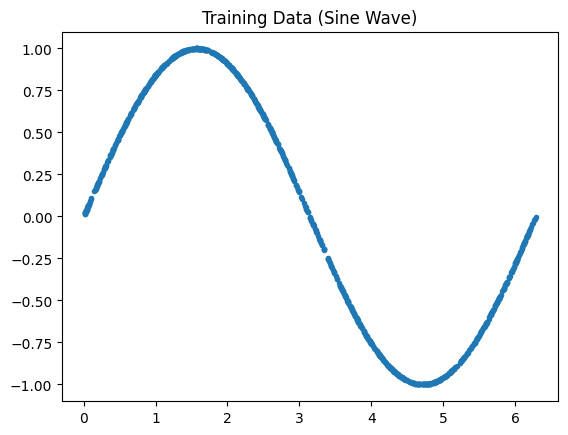

In [3]:
plt.plot(train_data[:,0], train_data[:,1], ".")
plt.title("Training Data (Sine Wave)")
plt.savefig(
    "sine_training_data.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [4]:
# DataLoader
batch_size = 32

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True
)

In [5]:
# Define Discriminator
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

discriminator = Discriminator()

In [6]:
# Define Generator
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),

            nn.Linear(16, 32),
            nn.ReLU(),

            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.model(x)

generator = Generator()

In [7]:
# Training Setup
lr = 0.001
num_epochs = 2000

loss_function = nn.BCELoss()

optimizer_discriminator = torch.optim.Adam(
    discriminator.parameters(),
    lr=lr
)

optimizer_generator = torch.optim.Adam(
    generator.parameters(),
    lr=lr
)

In [11]:
generator_losses = []
discriminator_losses = []

for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):

        # Labels
        real_samples_labels = torch.ones((batch_size, 1))
        latent_space_samples = torch.randn((batch_size, 2))
        generated_samples = generator(latent_space_samples)
        generated_samples_labels = torch.zeros((batch_size, 1))

        # Combine real + fake
        all_samples = torch.cat((real_samples, generated_samples))
        all_samples_labels = torch.cat(
            (real_samples_labels, generated_samples_labels)
        )

        # Train Discriminator
        discriminator.zero_grad()

        output_discriminator = discriminator(all_samples)

        loss_discriminator = loss_function(
            output_discriminator,
            all_samples_labels
        )

        loss_discriminator.backward()
        optimizer_discriminator.step()

        # Train Generator
        latent_space_samples = torch.randn((batch_size, 2))

        generator.zero_grad()

        generated_samples = generator(latent_space_samples)

        output_discriminator_generated = discriminator(generated_samples)

        loss_generator = loss_function(
            output_discriminator_generated,
            real_samples_labels
        )

        loss_generator.backward()
        optimizer_generator.step()

    # Store losses after each epoch
    generator_losses.append(loss_generator.item())
    discriminator_losses.append(loss_discriminator.item())

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D loss: {loss_discriminator:.4f} | G loss: {loss_generator:.4f}")

Epoch 0 | D loss: 0.7741 | G loss: 0.8083
Epoch 200 | D loss: 0.6827 | G loss: 0.8408
Epoch 400 | D loss: 0.6746 | G loss: 0.7410
Epoch 600 | D loss: 0.6949 | G loss: 0.7308
Epoch 800 | D loss: 0.6268 | G loss: 0.8057
Epoch 1000 | D loss: 0.6797 | G loss: 0.7913
Epoch 1200 | D loss: 0.6802 | G loss: 0.8286
Epoch 1400 | D loss: 0.5951 | G loss: 0.8059
Epoch 1600 | D loss: 0.6636 | G loss: 0.7274
Epoch 1800 | D loss: 0.6265 | G loss: 0.7615


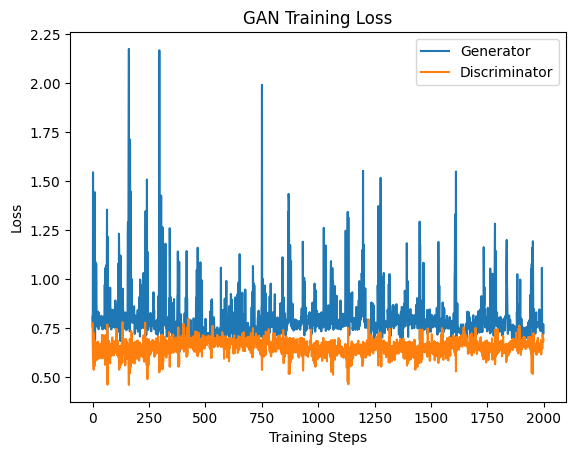

In [12]:
# loss plot
plt.plot(generator_losses,label="Generator")
plt.plot(discriminator_losses,label="Discriminator")

plt.title("GAN Training Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")

plt.legend()
plt.savefig(
    "gan_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

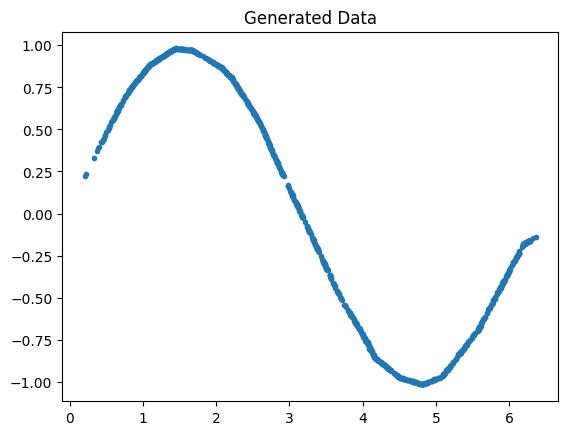

In [13]:
latent_space_samples = torch.randn(1000, 2)
generated_samples = generator(latent_space_samples)

generated_samples_numpy = generated_samples.detach().numpy()

plt.plot(
    generated_samples_numpy[:,0],
    generated_samples_numpy[:,1],
    "."
)

plt.title("Generated Data")
plt.savefig(
    "generated_samples.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

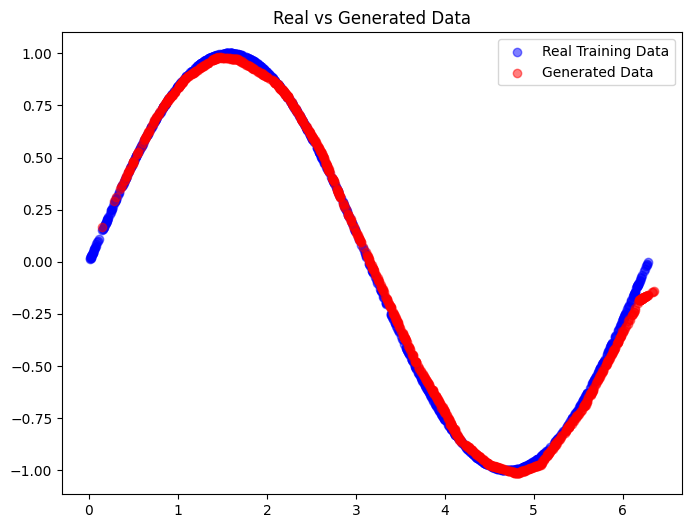

In [14]:
# Generate samples from the trained generator
latent_space_samples = torch.randn(1000, 2)
generated_samples = generator(latent_space_samples)
generated_samples = generated_samples.detach().numpy()

# Training data (convert to numpy for plotting)
train_data_numpy = train_data.numpy()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Real (training) data
plt.scatter(
    train_data_numpy[:,0],
    train_data_numpy[:,1],
    color="blue",
    alpha=0.5,
    label="Real Training Data"
)

# Fake (generated) data
plt.scatter(
    generated_samples[:,0],
    generated_samples[:,1],
    color="red",
    alpha=0.5,
    label="Generated Data"
)

plt.title("Real vs Generated Data")
plt.legend()
plt.savefig(
    "real_vs_generated.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Part 1
# Task 2
# 2D Spiral GAN

In [15]:


import torch
import matplotlib.pyplot as plt
import math


torch.manual_seed(42)


# Number of spiral points

train_data_length = 1024


# Create empty tensor

spiral_data = torch.zeros((train_data_length,2))


# Generate spiral angle

theta = torch.linspace(
    0,
    4 * math.pi,
    train_data_length
)


# Radius increases with angle

radius = torch.linspace(
    0.1,
    1,
    train_data_length
)


# Add small noise

noise = 0.05 * torch.randn(train_data_length)



# Spiral equation

spiral_data[:,0] = (
    radius * torch.cos(theta)
    + noise
)


spiral_data[:,1] = (
    radius * torch.sin(theta)
    + noise
)



# Labels (not used)

spiral_labels = torch.zeros(train_data_length)



# Create dataset

spiral_set = [
    (spiral_data[i], spiral_labels[i])
    for i in range(train_data_length)
]

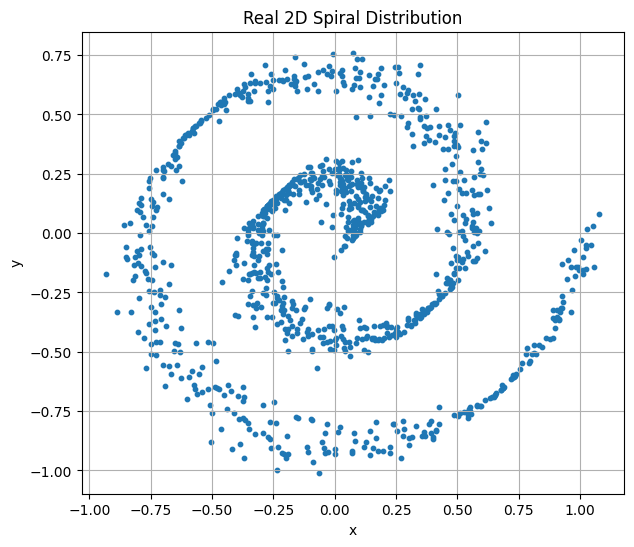

In [16]:
# Visualise Real Spiral Data
plt.figure(figsize=(7,6))


plt.scatter(
    spiral_data[:,0],
    spiral_data[:,1],
    s=10
)


plt.title("Real 2D Spiral Distribution")
plt.xlabel("x")
plt.ylabel("y")

plt.grid(True)
plt.savefig(
    "real_spiral.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [17]:
# DataLoader
batch_size = 32


spiral_loader = torch.utils.data.DataLoader(
    spiral_set,
    batch_size=batch_size,
    shuffle=True
)

In [18]:
# use GAN Models
# Define Discriminator
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

spiral_discriminator = Discriminator()

In [19]:
# Define Generator
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),

            nn.Linear(16, 32),
            nn.ReLU(),

            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.model(x)
spiral_generator = Generator()

In [20]:
# Training Setup
lr = 0.001

num_epochs = 2000


loss_function = nn.BCELoss()


optimizer_discriminator = torch.optim.Adam(
    spiral_discriminator.parameters(),
    lr=lr
)


optimizer_generator = torch.optim.Adam(
    spiral_generator.parameters(),
    lr=lr
)


generator_losses = []

discriminator_losses = []

In [21]:
spiral_optimizer_discriminator = torch.optim.Adam(
    spiral_discriminator.parameters(),
    lr=lr
)


spiral_optimizer_generator = torch.optim.Adam(
    spiral_generator.parameters(),
    lr=lr
)

In [22]:
# Train Spiral GAN

for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(spiral_loader):

        # Labels
        real_samples_labels = torch.ones((batch_size, 1))
        latent_space_samples = torch.randn((batch_size, 2))
        generated_samples = spiral_generator(latent_space_samples)
        generated_samples_labels = torch.zeros((batch_size, 1))

        # Combine real + fake
        all_samples = torch.cat((real_samples, generated_samples))
        all_samples_labels = torch.cat(
            (real_samples_labels, generated_samples_labels)
        )

        # Train Discriminator
        spiral_discriminator.zero_grad()

        output_discriminator = spiral_discriminator(all_samples)

        loss_discriminator = loss_function(
            output_discriminator,
            all_samples_labels
        )

        loss_discriminator.backward()
        spiral_optimizer_discriminator.step()

        # Train Generator
        latent_space_samples = torch.randn((batch_size, 2))

        spiral_generator.zero_grad()

        generated_samples = spiral_generator(latent_space_samples)

        output_discriminator_generated = spiral_discriminator(generated_samples)

        loss_generator = loss_function(
            output_discriminator_generated,
            real_samples_labels
        )

        loss_generator.backward()

        spiral_optimizer_generator.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D loss: {loss_discriminator:.4f} | G loss: {loss_generator:.4f}")

Epoch 0 | D loss: 0.5865 | G loss: 0.9482
Epoch 200 | D loss: 0.6934 | G loss: 0.6958
Epoch 400 | D loss: 0.7150 | G loss: 0.7114
Epoch 600 | D loss: 0.6931 | G loss: 0.6931
Epoch 800 | D loss: 0.6899 | G loss: 0.6934
Epoch 1000 | D loss: 0.6931 | G loss: 0.6932
Epoch 1200 | D loss: 0.6957 | G loss: 0.6611
Epoch 1400 | D loss: 0.7023 | G loss: 0.7493
Epoch 1600 | D loss: 0.6931 | G loss: 0.6932
Epoch 1800 | D loss: 0.6932 | G loss: 0.6934


In [23]:
# Generate Spiral Samples
latent_space_samples = torch.randn(1000,2)


generated_spiral = spiral_generator(
    latent_space_samples)


generated_spiral = generated_spiral.detach().numpy()

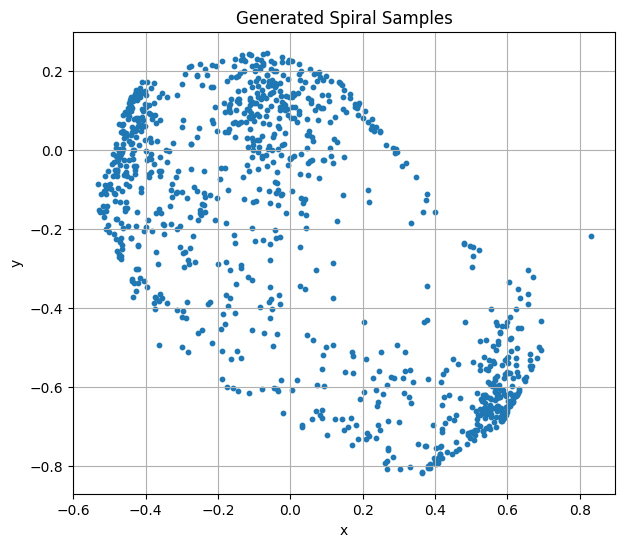

In [24]:
# Plot Generated Spiral
plt.figure(figsize=(7,6))


plt.scatter(
    generated_spiral[:,0],
    generated_spiral[:,1],
    s=10
)


plt.title(
    "Generated Spiral Samples"
)

plt.xlabel("x")
plt.ylabel("y")

plt.grid(True)
plt.savefig(
    "spiral_generated.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

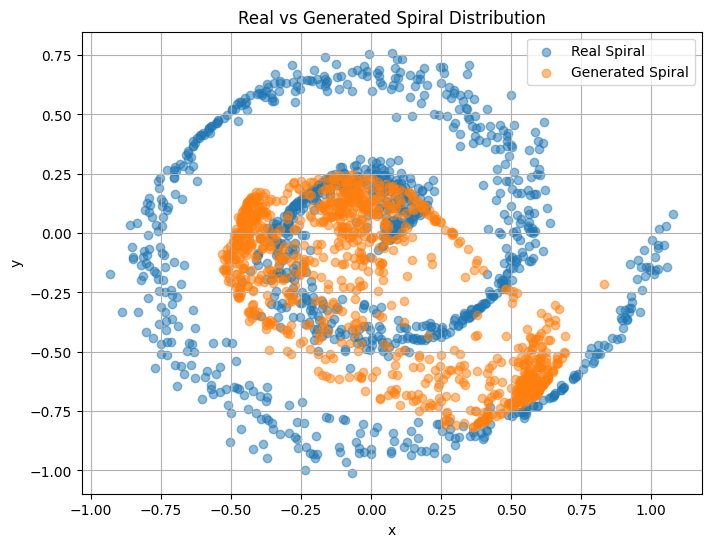

In [25]:
# Real vs Generated Comparison
plt.figure(figsize=(8,6))


plt.scatter(
    spiral_data[:,0],
    spiral_data[:,1],
    alpha=0.5,
    label="Real Spiral"
)


plt.scatter(
    generated_spiral[:,0],
    generated_spiral[:,1],
    alpha=0.5,
    label="Generated Spiral"
)


plt.title(
    "Real vs Generated Spiral Distribution"
)


plt.xlabel("x")
plt.ylabel("y")


plt.legend()

plt.grid(True)
plt.savefig(
    "spiral_real_vs_generated.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#Part 1
# Task 3
 Modified GAN architecture and comparison.

In [26]:
# Modified GAN Architecture
# Modified Discriminator using LeakyReLU



class ModifiedDiscriminator(nn.Module):

    def __init__(self):

        super().__init__()


        self.model = nn.Sequential(

            nn.Linear(2,256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),


            nn.Linear(256,128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),


            nn.Linear(128,64),
            nn.LeakyReLU(0.2),


            nn.Linear(64,1),
            nn.Sigmoid()

        )


    def forward(self,x):

        return self.model(x)



modified_discriminator = ModifiedDiscriminator()

In [27]:
# Define Modified Generator
# Deeper network with LeakyReLU


class ModifiedGenerator(nn.Module):

    def __init__(self):

        super().__init__()


        self.model = nn.Sequential(

            nn.Linear(2,32),
            nn.LeakyReLU(0.2),


            nn.Linear(32,64),
            nn.LeakyReLU(0.2),


            nn.Linear(64,32),
            nn.LeakyReLU(0.2),


            nn.Linear(32,2)

        )


    def forward(self,x):

        return self.model(x)



modified_generator = ModifiedGenerator()

In [28]:
# Optimisers
# Training setup

lr = 0.001


modified_optimizer_discriminator = torch.optim.Adam(
    modified_discriminator.parameters(),
    lr=lr
)


modified_optimizer_generator = torch.optim.Adam(
    modified_generator.parameters(),
    lr=lr
)


modified_generator_losses = []

modified_discriminator_losses = []

In [30]:
# Train Modified GAN

for epoch in range(num_epochs):


    for real_samples, _ in spiral_loader:

        # Train Discriminator

       real_labels = torch.ones( (batch_size,1))

       fake_labels = torch.zeros((batch_size,1))
       noise = torch.randn((batch_size,2))
       fake_samples = modified_generator(noise )

       all_samples = torch.cat(
            (
                real_samples,
                fake_samples
            )
        )
       all_labels = torch.cat(
            (
                real_labels,
                fake_labels
            )
        )
       modified_discriminator.zero_grad()

       output = modified_discriminator(
            all_samples
        )
       d_loss = loss_function(
            output,
            all_labels
        )
       d_loss.backward()
       modified_optimizer_discriminator.step()

        # Train Generator
       noise = torch.randn(
            (batch_size,2)
        )
       modified_generator.zero_grad()
       fake_samples = modified_generator(
            noise
        )
       output = modified_discriminator(
            fake_samples
        )


       g_loss = loss_function(
            output,
            real_labels
        )

       g_loss.backward()

       modified_optimizer_generator.step()

    modified_generator_losses.append(
            g_loss.item()
        )
    modified_discriminator_losses.append(
            d_loss.item()
        )


    if epoch % 200 == 0:

        print(
            f"Epoch {epoch} | "f"D Loss: {d_loss.item():.4f} | "f"G Loss: {g_loss.item():.4f}"
        )

Epoch 0 | D Loss: 0.6046 | G Loss: 0.8814
Epoch 200 | D Loss: 0.7308 | G Loss: 0.9088
Epoch 400 | D Loss: 0.6966 | G Loss: 0.7896
Epoch 600 | D Loss: 0.6811 | G Loss: 0.7835
Epoch 800 | D Loss: 0.6774 | G Loss: 0.7355
Epoch 1000 | D Loss: 0.6615 | G Loss: 0.6945
Epoch 1200 | D Loss: 0.6899 | G Loss: 0.7393
Epoch 1400 | D Loss: 0.6912 | G Loss: 0.7114
Epoch 1600 | D Loss: 0.6692 | G Loss: 0.6717
Epoch 1800 | D Loss: 0.6497 | G Loss: 0.8283


In [31]:
# Generate Modified GAN Samples
noise = torch.randn(1000,2)


modified_samples = modified_generator(
    noise
)


modified_samples = modified_samples.detach().numpy()

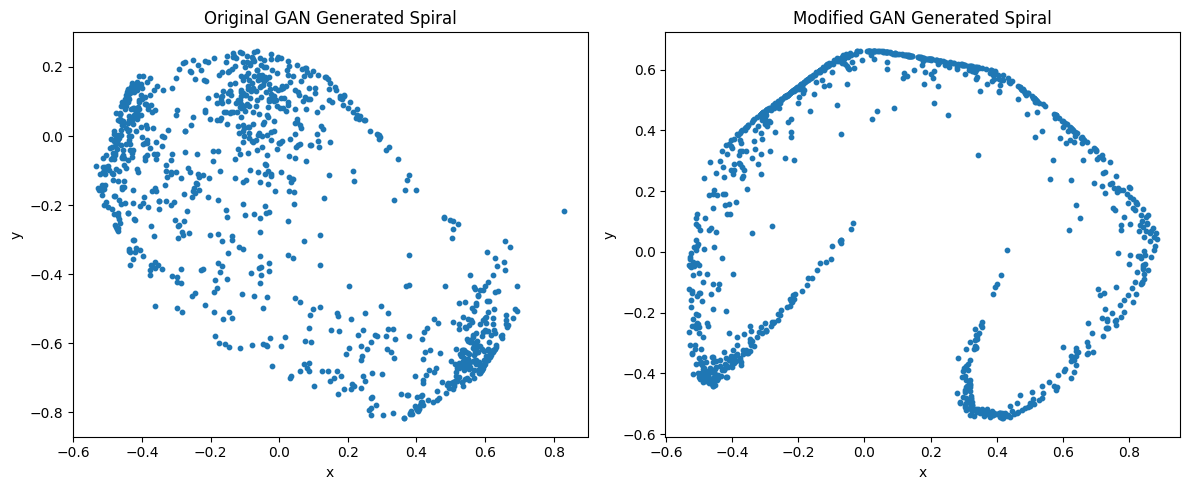

In [32]:
# Compare Original vs Modified GAN
plt.figure(figsize=(12,5))


# Original GAN

plt.subplot(1,2,1)

plt.scatter(
    generated_spiral[:,0],
    generated_spiral[:,1],
    s=10
)

plt.title(
    "Original GAN Generated Spiral"
)

plt.xlabel("x")
plt.ylabel("y")



# Modified GAN

plt.subplot(1,2,2)

plt.scatter(
    modified_samples[:,0],
    modified_samples[:,1],
    s=10
)

plt.title(
    "Modified GAN Generated Spiral"
)

plt.xlabel("x")
plt.ylabel("y")


plt.tight_layout()
plt.savefig(
    "original_vs_modified_GAN.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Real-World GAN Applications
# Work through three real-world GAN applications
# Part 2.1 — Medical Application: OCTMNIST Retinal Images with DCGAN.

In [ ]:
# Part 2.1 — OCTMNIST DCGAN
# Install MedMNIST
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 11.2 MB/s eta 0:00:00


In [ ]:
# Import Libraries
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

import medmnist
from medmnist import OCTMNIST


print(torch.__version__)

2.11.0+cu128


In [ ]:
# Load OCTMNIST Dataset
# Image preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])


# Training dataset

train_dataset = OCTMNIST(
    split="train",
    transform=transform,
    download=True
)


# Test dataset

test_dataset = OCTMNIST(
    split="test",
    transform=transform,
    download=True
)


print(
    "Training images:",
    len(train_dataset)
)

print(
    "Testing images:",
    len(test_dataset)
)

100%|██████████| 54.9M/54.9M [00:12<00:00, 4.52MB/s]


Training images: 97477
Testing images: 1000


In [ ]:
# Explore Image Shape
image, label = train_dataset[0]


print("Image shape:", image.shape)

print("Class label:", label)

Image shape: torch.Size([1, 28, 28])
Class label: [0]


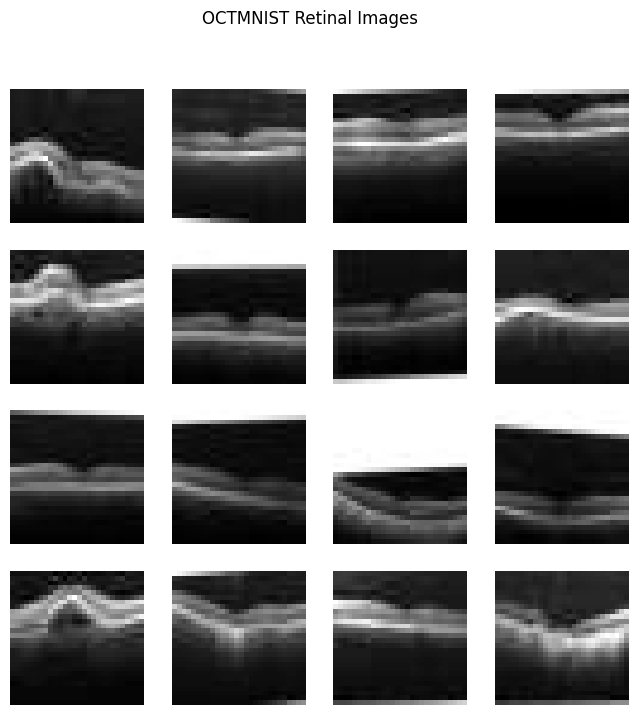

In [ ]:
# Display OCT Images
plt.figure(figsize=(8,8))


for i in range(16):

    image, label = train_dataset[i]


    plt.subplot(4,4,i+1)


    plt.imshow(
        image.squeeze(),
        cmap="gray"
    )


    plt.axis("off")


plt.suptitle(
    "OCTMNIST Retinal Images"
)

plt.savefig(
    "octmnist_samples.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# Create DataLoader
batch_size = 128


train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

In [ ]:
# Build DCGAN Generator

class Generator(nn.Module):

    def __init__(self, latent_dim=100):

        super().__init__()

        self.model = nn.Sequential(

            # 100 x 1 x 1
            nn.ConvTranspose2d(
                latent_dim,
                128,
                kernel_size=7,
                stride=1,
                padding=0
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(True),


            # 128 x 7 x 7
            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(True),


            # 64 x 14 x 14
            nn.ConvTranspose2d(
                64,
                1,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            # Output between -1 and 1
            nn.Tanh()
        )


    def forward(self,x):

        return self.model(x)



generator = Generator()


print(generator)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Tanh()
  )
)


In [ ]:
# Build DCGAN Discriminator
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()


        self.model = nn.Sequential(

            # 1 x 28 x 28
            nn.Conv2d(
                1,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            # 64 x 14 x 14
            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            nn.Flatten(),


            nn.Linear(
                128*7*7,
                1
            ),

            nn.Sigmoid()
        )


    def forward(self,x):

        return self.model(x)



discriminator = Discriminator()


print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Linear(in_features=6272, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [ ]:
# Test Generator Output
latent_dim = 100

noise = torch.randn(
    16,
    latent_dim,
    1,
    1
)


fake_images = generator(noise)


print(fake_images.shape)

torch.Size([16, 1, 28, 28])


In [ ]:
# DCGAN Training Setup

latent_dim = 100

learning_rate = 0.0002

# Define device and move models to it
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
generator.to(device)
discriminator.to(device)

# Binary cross entropy loss

loss_function = nn.BCELoss()



# Optimizers (initialized *after* models are on device)

optimizer_generator = torch.optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(0.5,0.999)
)


optimizer_discriminator = torch.optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5,0.999)
)



# Store losses

generator_losses = []

discriminator_losses = []


print("Training setup complete")

Training setup complete


In [ ]:
torch.cuda.is_available()

True

In [ ]:
# DCGAN Training Loop

num_epochs = 30


for epoch in range(num_epochs):


    for real_images, _ in train_loader:


        batch_size = real_images.size(0)

        # Move real images to device
        real_images = real_images.to(device)

        # Train Discriminator

        # Move labels to device
        real_labels = torch.ones( batch_size, 1).to(device)


        fake_labels = torch.zeros( batch_size, 1).to(device)


        discriminator.zero_grad()



        real_output = discriminator(  real_images )


        real_loss = loss_function(real_output, real_labels)


        # Move noise to device
        noise = torch.randn(  batch_size,  latent_dim,  1,  1).to(device)


        fake_images = generator(
            noise
        )


        fake_output = discriminator(
            fake_images.detach()
        )


        fake_loss = loss_function(
            fake_output,
            fake_labels
        )



        discriminator_loss = (
            real_loss +
            fake_loss
        )


        discriminator_loss.backward()

        optimizer_discriminator.step()



        # Train Generator


        generator.zero_grad()



        fake_output = discriminator(fake_images)


        generator_loss = loss_function( fake_output,real_labels)


        generator_loss.backward()


        optimizer_generator.step()



        # Save losses

        generator_losses.append(
            generator_loss.item() )

        discriminator_losses.append(
            discriminator_loss.item())



    if epoch % 5 == 0:

        print(
            f"Epoch {epoch} | "f"D Loss: {discriminator_loss.item():.4f} | G Loss: {generator_loss.item():.4f}"
        )

Epoch 0 | D Loss: 0.6304 | G Loss: 1.6731
Epoch 5 | D Loss: 0.4579 | G Loss: 2.5508
Epoch 10 | D Loss: 0.1795 | G Loss: 3.0954
Epoch 15 | D Loss: 0.2218 | G Loss: 3.0190
Epoch 20 | D Loss: 0.0950 | G Loss: 3.6146
Epoch 25 | D Loss: 0.4644 | G Loss: 7.7367


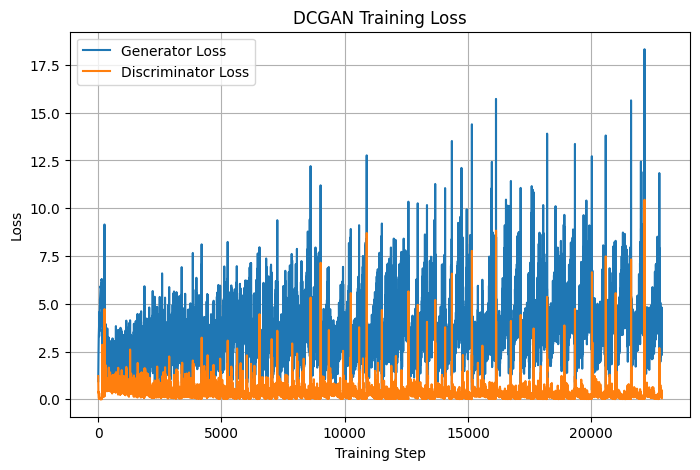

In [ ]:
# DCGAN Training Loss

plt.figure(figsize=(8,5))

plt.plot(generator_losses, label="Generator Loss")
plt.plot(discriminator_losses, label="Discriminator Loss")

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("DCGAN Training Loss")

plt.legend()
plt.grid(True)

plt.savefig(
    "oct_dcgan_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

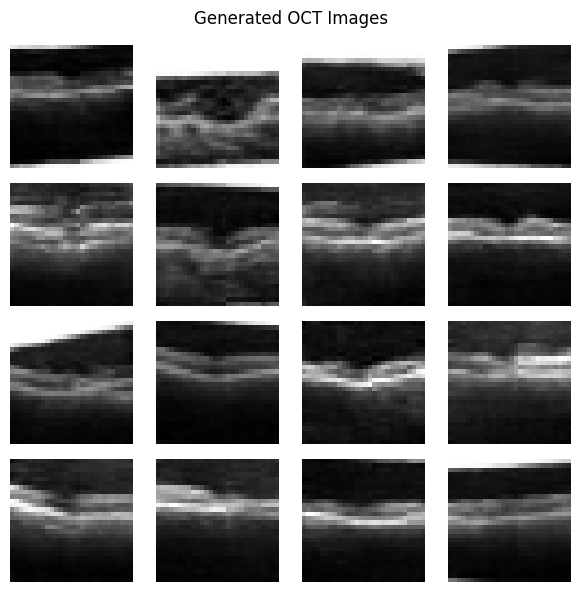

In [ ]:
# Generate Fake OCT Images

generator.eval()

noise = torch.randn(16, latent_dim, 1, 1, device=device)

with torch.no_grad():
    fake_images = generator(noise).cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(fake_images[i, 0], cmap="gray")
    ax.axis("off")

plt.suptitle("Generated OCT Images")
plt.tight_layout()

plt.savefig("generated_oct_images.png", dpi=300, bbox_inches="tight")
plt.show()

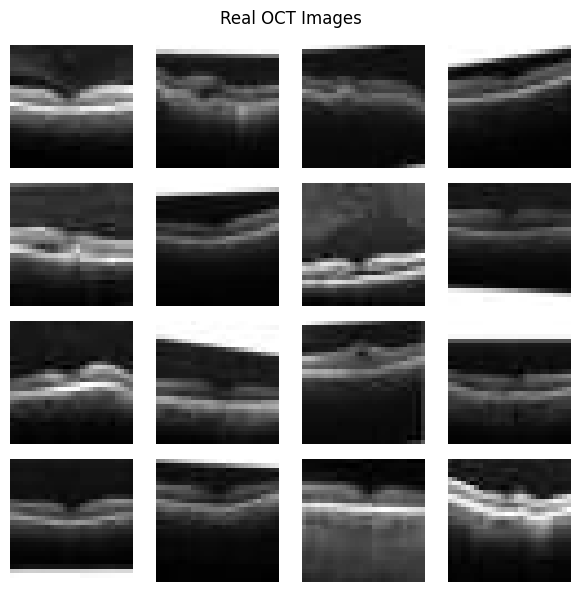

In [ ]:
# Real OCT Images


real_batch = next(iter(train_loader))

real_images = real_batch[0][:16]


fig, axes = plt.subplots(4,4,figsize=(6,6))

for i, ax in enumerate(axes.flat):

    ax.imshow(
        real_images[i,0],
        cmap="gray"
    )

    ax.axis("off")

plt.suptitle("Real OCT Images")

plt.tight_layout()

plt.savefig(
    "real_oct_images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

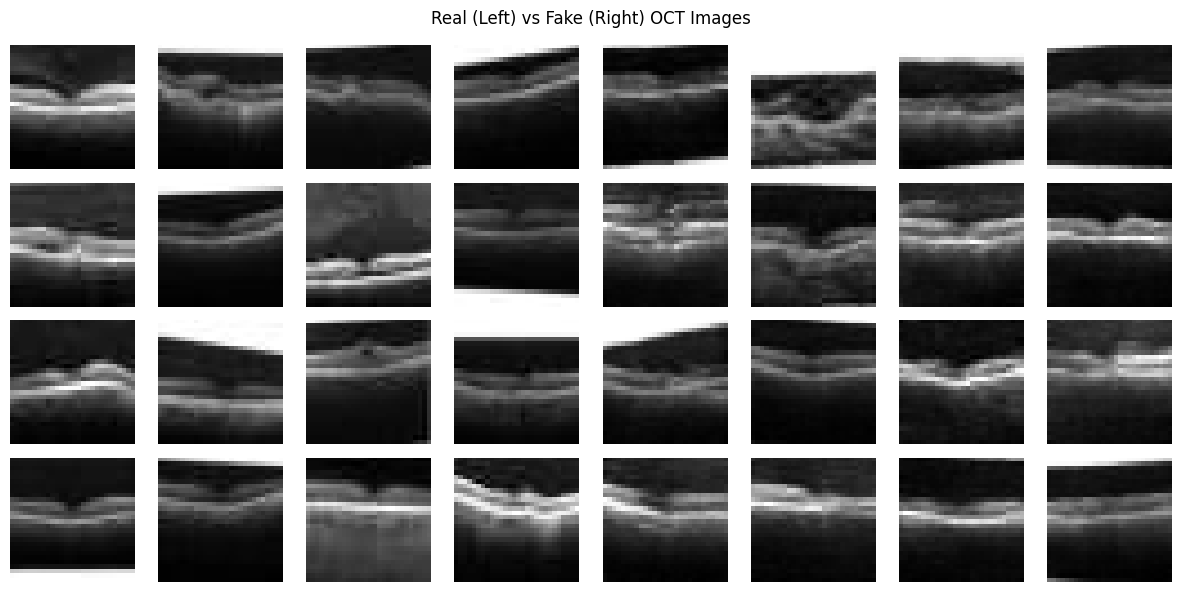

In [ ]:
# Real vs Fake OCT Images
# ==========================================================

fig, axes = plt.subplots(
    4,
    8,
    figsize=(12,6)
)

for i in range(16):

    # Real image

    axes[i//4, (i%4)].imshow(
        real_images[i,0],
        cmap="gray"
    )

    axes[i//4, (i%4)].axis("off")


    # Fake image

    axes[i//4, (i%4)+4].imshow(
        fake_images[i,0],
        cmap="gray"
    )

    axes[i//4, (i%4)+4].axis("off")

plt.suptitle("Real (Left) vs Fake (Right) OCT Images")

plt.tight_layout()

plt.savefig(
    "real_vs_fake_oct.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 57.6 MB/s eta 0:00:00


In [ ]:
# Import FID
from torchmetrics.image.fid import FrechetInceptionDistance
import torchvision.transforms as transforms

In [ ]:
import torchvision.transforms as transforms
import sys

# Create FID Metric
# Install or update torchmetrics with the image dependencies
!pip install -U torchmetrics[image]

# Clear torchmetrics and its submodules from sys.modules to force a fresh import
# This ensures the internal _TORCH_FIDELITY_AVAILABLE flag is re-evaluated.
for module_name in list(sys.modules.keys()):
    if module_name.startswith('torchmetrics') or module_name.startswith('torch_fidelity'):
        del sys.modules[module_name]

# Now, import FrechetInceptionDistance. This will force a fresh load
# and properly detect the installed torch-fidelity.
from torchmetrics.image.fid import FrechetInceptionDistance

fid = FrechetInceptionDistance(feature=2048)

resize = transforms.Compose([
    transforms.Resize((299,299))
])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.8 MB/s eta 0:00:00


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 379MB/s]


In [ ]:
# Collect Real and Fake Images
generator.eval()

real_images_list = []
fake_images_list = []

with torch.no_grad():

    for real_images, _ in train_loader:

        real_images = real_images.to(device)

        noise = torch.randn(
            real_images.size(0),
            latent_dim,
            1,
            1,
            device=device
        )

        fake_images = generator(noise)

        real_images_list.append(real_images.cpu())
        fake_images_list.append(fake_images.cpu())

        # Use only the first 10 batches for faster FID computation
        if len(real_images_list) == 10:
            break

In [ ]:
print("Number of real batches:", len(real_images_list))
print("Number of fake batches:", len(fake_images_list))

print("Real image shape:", real_images_list[0].shape)
print("Fake image shape:", fake_images_list[0].shape)

Number of real batches: 10
Number of fake batches: 10
Real image shape: torch.Size([128, 1, 28, 28])
Fake image shape: torch.Size([128, 1, 28, 28])


In [ ]:
# FID calculation
for real, fake in zip(real_images_list, fake_images_list):

    # Resize images
    real = resize(real)
    fake = resize(fake)

    # Convert grayscale (1 channel) to RGB (3 channels)
    real = real.repeat(1, 3, 1, 1)
    fake = fake.repeat(1, 3, 1, 1)

    # Convert [-1,1] to [0,255]
    real = ((real + 1) / 2 * 255).clamp(0,255).to(torch.uint8)
    fake = ((fake + 1) / 2 * 255).clamp(0,255).to(torch.uint8)

    # Update FID
    fid.update(real, real=True)
    fid.update(fake, real=False)


fid_score = fid.compute()

print("FID Score:", fid_score.item())

FID Score: 49.14783477783203


# Part 2.2 — CICIDS 2017 Cybersecurity GAN.

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files

files.upload()

Saving archive (2).zip to archive (2).zip


In [ ]:
# Extract Dataset
import zipfile
import os

zip_path = "archive (2).zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("CICIDS2017")

print("Extraction completed")

Extraction completed


In [ ]:
# Check Extracted Files


os.listdir("CICIDS2017")

['Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
 'Monday-WorkingHours.pcap_ISCX.csv',
 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
 'Friday-WorkingHours-Morning.pcap_ISCX.csv',
 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
 'Wednesday-workingHours.pcap_ISCX.csv',
 'Tuesday-WorkingHours.pcap_ISCX.csv',
 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv']

In [ ]:
# Load Wednesday Dataset



import pandas as pd

file_path = "CICIDS2017/Wednesday-workingHours.pcap_ISCX.csv"

df = pd.read_csv(file_path)

df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
df.shape

(692703, 79)

In [ ]:
df.columns = df.columns.str.strip()

df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
# Check Class Distribution
df["Label"].value_counts()

,count
Label,
BENIGN,440031
DoS Hulk,231073
DoS GoldenEye,10293
DoS slowloris,5796
DoS Slowhttptest,5499
Heartbleed,11


In [ ]:
# Select BENIGN + DoS classes



df_gan = df[
    df["Label"].isin([
        "BENIGN",
        "DoS Hulk",
        "DoS GoldenEye",
        "DoS slowloris",
        "DoS Slowhttptest"
    ])
]

print(df_gan.shape)

(692692, 79)


In [ ]:
# Check selected classes



df_gan["Label"].value_counts()

,count
Label,
BENIGN,440031
DoS Hulk,231073
DoS GoldenEye,10293
DoS slowloris,5796
DoS Slowhttptest,5499


In [ ]:
# Remove Label column
X = df_gan.drop("Label", axis=1)

print(X.shape)

(692692, 78)


In [ ]:
# Handle Infinite Values and Missing Values

import numpy as np

# Replace infinite values
X = X.replace([np.inf, -np.inf], np.nan)

# Replace missing values
X = X.fillna(0)

print("Missing values:", X.isnull().sum().sum())

Missing values: 0


In [ ]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(692692, 78)


In [ ]:
# Convert Data to PyTorch Tensor
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

real_data = torch.tensor(
    X_scaled,
    dtype=torch.float32
)

print(real_data.shape)
print(device)

torch.Size([692692, 78])
cpu


In [ ]:
# Create DataLoader

from torch.utils.data import DataLoader, TensorDataset

batch_size = 128

dataset = TensorDataset(real_data)

train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

print(len(train_loader))

5412


In [ ]:
# Define Generator
import torch.nn as nn


latent_dim = 100
feature_dim = 78


class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(latent_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, feature_dim)
        )


    def forward(self, x):
        return self.model(x)

In [ ]:
# Define Discriminator
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(feature_dim, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2),

            nn.Linear(256,1),
            nn.Sigmoid()
        )


    def forward(self,x):
        return self.model(x)

In [ ]:
# Create Models
generator = Generator().to(device)

discriminator = Discriminator().to(device)


print(generator)
print(discriminator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=78, bias=True)
  )
)
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=78, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [ ]:
# Loss Function and Optimizers

import torch.optim as optim

loss_function = nn.BCELoss()


optimizer_generator = optim.Adam(
    generator.parameters(),
    lr=0.0002
)


optimizer_discriminator = optim.Adam(
    discriminator.parameters(),
    lr=0.0002
)


generator_losses = []
discriminator_losses = []

In [ ]:
print(len(train_loader.dataset))

692692


In [ ]:
# Randomly select 20,000 samples

sample_size = 20000

indices = np.random.choice(
    X_scaled.shape[0],
    sample_size,
    replace=False
)

X_train = X_scaled[indices]

In [ ]:
import torch

train_tensor = torch.FloatTensor(X_train)

train_dataset = torch.utils.data.TensorDataset(train_tensor)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

In [ ]:
print(len(train_loader.dataset))

20000


In [ ]:
# GAN Training Loop


num_epochs = 30


for epoch in range(num_epochs):

    for real_batch, in train_loader:


        real_batch = real_batch.to(device)

        batch_size = real_batch.size(0)


        # Labels

        real_labels = torch.ones(
            batch_size,
            1,
            device=device
        )

        fake_labels = torch.zeros(
            batch_size,
            1,
            device=device
        )


        # Train Discriminator

        discriminator.zero_grad()


        real_output = discriminator(
            real_batch
        )


        real_loss = loss_function(
            real_output,
            real_labels
        )


        # Generate fake traffic

        noise = torch.randn(
            batch_size,
            latent_dim,
            device=device
        )


        fake_data = generator(
            noise
        )


        fake_output = discriminator(
            fake_data.detach()
        )


        fake_loss = loss_function(
            fake_output,
            fake_labels
        )


        discriminator_loss = (
            real_loss + fake_loss
        )


        discriminator_loss.backward()

        optimizer_discriminator.step()

      # Train Generator


        generator.zero_grad()


        fake_output = discriminator(
            fake_data
        )


        generator_loss = loss_function(
            fake_output,
            real_labels
        )


        generator_loss.backward()

        optimizer_generator.step()



        # Save losses

        generator_losses.append(
            generator_loss.item()
        )

        discriminator_losses.append(
            discriminator_loss.item()
        )



    if epoch % 5 == 0:

        print(
            f"Epoch {epoch} | "
            f"D Loss: {discriminator_loss.item():.4f} | "
            f"G Loss: {generator_loss.item():.4f}"
        )

Epoch 0 | D Loss: 0.8483 | G Loss: 1.7123
Epoch 5 | D Loss: 0.3724 | G Loss: 2.5619
Epoch 10 | D Loss: 0.2113 | G Loss: 3.0798
Epoch 15 | D Loss: 0.2514 | G Loss: 7.3157
Epoch 20 | D Loss: 0.1641 | G Loss: 5.8689
Epoch 25 | D Loss: 0.2669 | G Loss: 4.6196


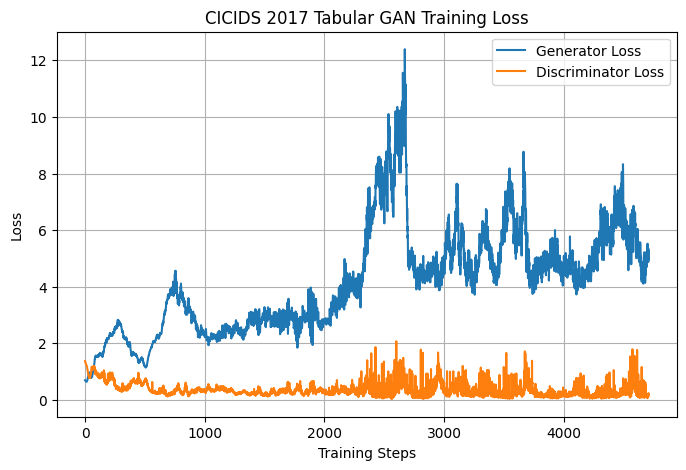

In [ ]:
import matplotlib.pyplot as plt

# Plot GAN training losses Curves

plt.figure(figsize=(8,5))

plt.plot(
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Training Steps")
plt.ylabel("Loss")

plt.title(
    "CICIDS 2017 Tabular GAN Training Loss"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "cicids_gan_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Generate Synthetic Network Traffic


generator.eval()

with torch.no_grad():

    noise = torch.randn(
        5000,
        latent_dim,
        device=device
    )

    synthetic_data = generator(
        noise
    )


synthetic_data = synthetic_data.cpu().numpy()


print(
    synthetic_data.shape
)

(5000, 78)


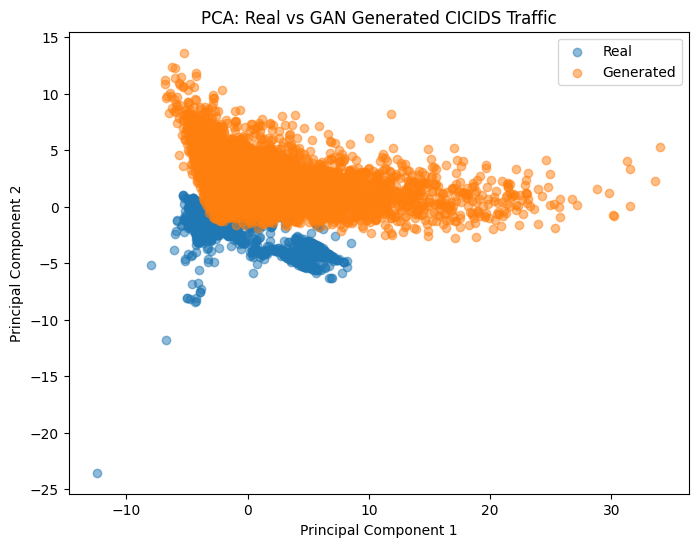

In [ ]:
# PCA visualisation
# compare real vs generated
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

real_sample = X_train[:5000]

combined = np.vstack(
    (real_sample, synthetic_data)
)

pca = PCA(n_components=2)

pca_data = pca.fit_transform(combined)


plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:5000,0],
    pca_data[:5000,1],
    alpha=0.5,
    label="Real"
)

plt.scatter(
    pca_data[5000:,0],
    pca_data[5000:,1],
    alpha=0.5,
    label="Generated"
)

plt.title("PCA: Real vs GAN Generated CICIDS Traffic")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()

plt.savefig(
    "cicids_pca_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

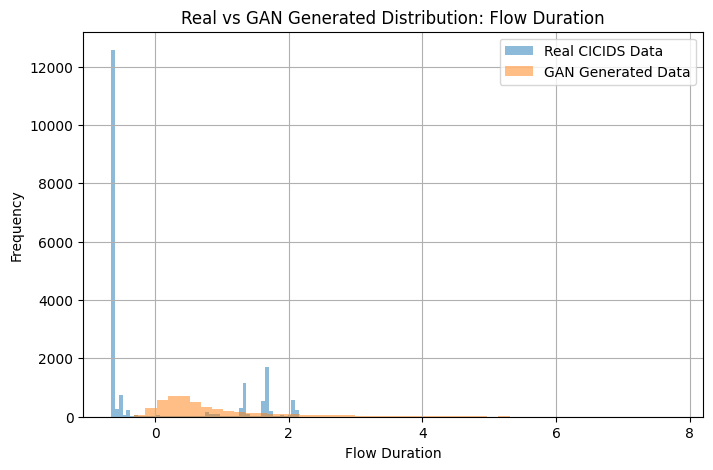

In [ ]:
# Compare Real vs GAN Generated CICIDS Traffic Distribution

import matplotlib.pyplot as plt

# Choose feature
feature_name = "Flow Duration"

# Find feature index
feature_index = X.columns.get_loc(feature_name)

# Extract real and generated feature values
real_feature = X_train[:, feature_index].flatten()
fake_feature = synthetic_data[:, feature_index].flatten()


plt.figure(figsize=(8,5))

plt.hist(
    real_feature,
    bins=50,
    alpha=0.5,
    label="Real CICIDS Data"
)

plt.hist(
    fake_feature,
    bins=50,
    alpha=0.5,
    label="GAN Generated Data"
)


plt.xlabel(feature_name)
plt.ylabel("Frequency")
plt.title(
    f"Real vs GAN Generated Distribution: {feature_name}"
)

plt.legend()
plt.grid(True)

plt.savefig(
    "real_vs_generated_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

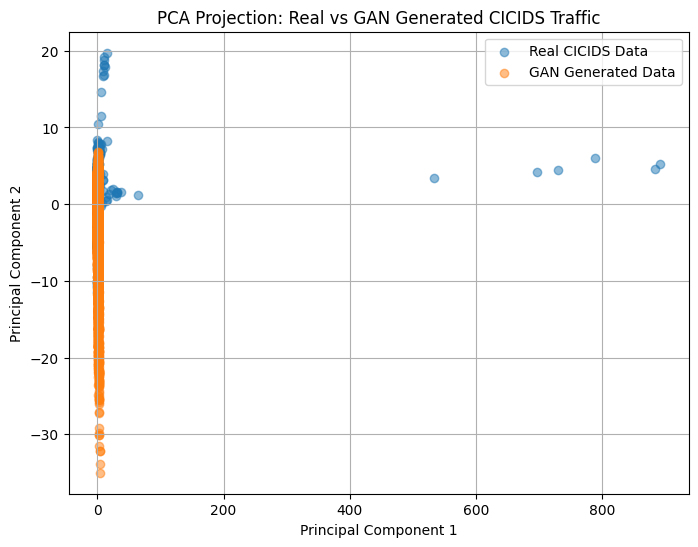

In [ ]:
# PCA Visualisation: Real vs GAN Generated CICIDS Traffic

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np


# Combine real and generated samples
combined_data = np.vstack(
    (
        real_samples[:5000],
        synthetic_data[:5000]
    )
)


# PCA reduction to 2 dimensions
pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    combined_data
)


plt.figure(figsize=(8,6))


# Real data
plt.scatter(
    pca_data[:5000,0],
    pca_data[:5000,1],
    alpha=0.5,
    label="Real CICIDS Data"
)


# Generated data
plt.scatter(
    pca_data[5000:,0],
    pca_data[5000:,1],
    alpha=0.5,
    label="GAN Generated Data"
)


plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "PCA Projection: Real vs GAN Generated CICIDS Traffic"
)


plt.legend()
plt.grid(True)


plt.savefig(
    "cicids_gan_pca_comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# # Convert GAN Generated Samples into DataFrame
generated_df = pd.DataFrame(
    synthetic_data,
    columns=X.columns
)


print(generated_df.head())

   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0         -1.695335       2.037049          -0.148207                1.382864   
1         -0.474952       2.579147           0.244380                1.525887   
2         -0.340994       0.482950          -0.104153                0.636610   
3         -0.321165       1.034547           0.025177                1.215388   
4         -0.094591       0.307366          -0.198536                0.734325   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                     0.615278                     0.737933   
1                     0.193166                     0.718238   
2                     0.473432                     0.201356   
3                     0.663090                     0.477048   
4                     0.822524                     0.352775   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0               0.707012              -1.122402            

In [ ]:
# Statistical comparison between real and generated data

comparison = pd.DataFrame({
    "Real Mean": X_train.mean(axis=0),
    "Generated Mean": synthetic_data.mean(axis=0),
    "Real Std": X_train.std(axis=0),
    "Generated Std": synthetic_data.std(axis=0)
}, index=X.columns)


comparison.head()

,Real Mean,Generated Mean,Real Std,Generated Std
Destination Port,-0.005986,-0.384636,0.992476,0.509604
Flow Duration,-0.006386,0.982346,1.000152,1.119918
Total Fwd Packets,-0.004721,0.017884,0.046805,0.096389
Total Backward Packets,-0.004704,0.732205,0.044603,0.362945
Total Length of Fwd Packets,-0.005917,0.375896,0.624716,0.249438


In [ ]:
# Correlation between real and generated feature statistics

correlation = np.corrcoef(
    X_train.mean(axis=0),
    synthetic_data.mean(axis=0)
)[0,1]


print(
    "Mean feature correlation:",
    correlation
)

Mean feature correlation: 0.1890754313313951


# Part 2.
task3 — Creative Arts GAN

In [ ]:

# Import Libraries and Setup Device



import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np


# Check device

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


print("Using device:", device)

Using device: cpu


In [ ]:
# Cell 2: Load Fashion-MNIST Dataset



transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])


train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)


print("Training samples:", len(train_dataset))


# Check image shape

images, labels = next(iter(train_loader))

print("Image shape:", images.shape)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.6MB/s]

Training samples: 60000
Image shape: torch.Size([128, 1, 28, 28])


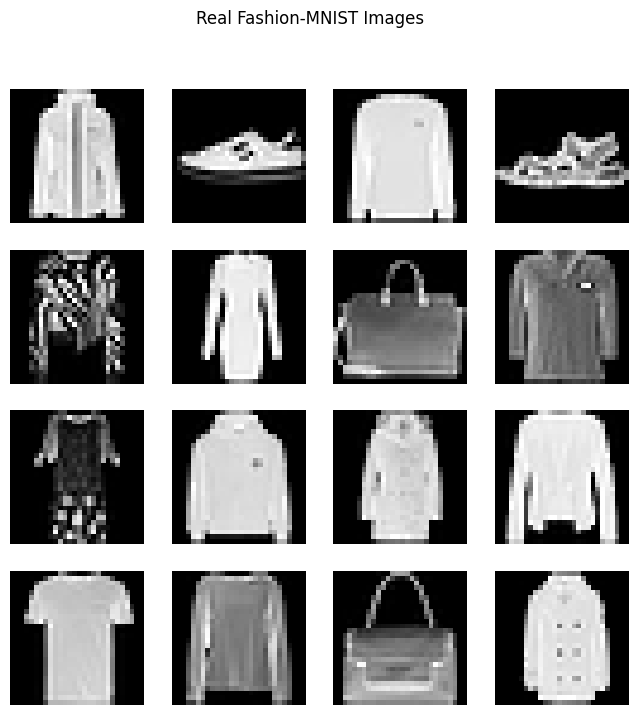

In [ ]:
#  Visualise Real Creative Images



# Get one batch

real_images, labels = next(iter(train_loader))


plt.figure(figsize=(8,8))


for i in range(16):

    plt.subplot(4,4,i+1)

    # Convert from [-1,1] back to [0,1]
    image = real_images[i].squeeze()

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.axis("off")


plt.suptitle(
    "Real Fashion-MNIST Images"
)

plt.show()

In [ ]:
# Generator Network



class Generator(nn.Module):

    def __init__(self, latent_dim):

        super().__init__()

        self.model = nn.Sequential(

            # Noise vector -> feature map
            nn.ConvTranspose2d(
                latent_dim,
                128,
                kernel_size=7,
                stride=1,
                padding=0
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(True),


            # 7x7 -> 14x14

            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(True),


            # 14x14 -> 28x28

            nn.ConvTranspose2d(
                64,
                1,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.Tanh()
        )


    def forward(self, x):

        return self.model(x)



# Latent noise size

latent_dim = 100


# Create Generator

generator = Generator(
    latent_dim
).to(device)


print(generator)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Tanh()
  )
)


In [ ]:
 # Discriminator Network


class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            # 28x28 -> 14x14

            nn.Conv2d(
                1,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            # 14x14 -> 7x7

            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            nn.Flatten(),


            nn.Linear(
                128 * 7 * 7,
                1
            ),

            nn.Sigmoid()
        )


    def forward(self, x):

        return self.model(x)



# Create discriminator

discriminator = Discriminator().to(device)


print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Linear(in_features=6272, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [ ]:
# Loss Function and Optimizers


# Binary classification loss

loss_function = nn.BCELoss()


# Optimizers

learning_rate = 0.0002


optimizer_generator = optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)


optimizer_discriminator = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)


# Store losses for plotting

generator_losses = []

discriminator_losses = []


print("Loss function and optimizers created successfully")

Loss function and optimizers created successfully


In [ ]:
#  Test Generator and Discriminator



# Create random noise

noise = torch.randn(
    16,
    latent_dim,
    1,
    1,
    device=device
)


# Generate fake images

fake_images = generator(
    noise
)


print("Generated image shape:")
print(fake_images.shape)



# Pass fake images through discriminator

output = discriminator(
    fake_images
)


print("\nDiscriminator output shape:")
print(output.shape)

Generated image shape:
torch.Size([16, 1, 28, 28])

Discriminator output shape:
torch.Size([16, 1])


In [ ]:
small_dataset = torch.utils.data.Subset(
    train_dataset,
    range(10000)
)


train_loader = DataLoader(
    small_dataset,
    batch_size=128,
    shuffle=True
)


print(len(small_dataset))

10000


In [ ]:
#  GAN Training Loop


num_epochs = 20


for epoch in range(num_epochs):

    for real_images, _ in train_loader:


        real_images = real_images.to(device)

        batch_size = real_images.size(0)


        # Labels

        real_labels = torch.ones(
            batch_size,
            1,
            device=device
        )

        fake_labels = torch.zeros(
            batch_size,
            1,
            device=device
        )


        # -----------------------
        # Train Discriminator
        # -----------------------

        discriminator.zero_grad()


        # Real images

        real_output = discriminator(
            real_images
        )

        real_loss = loss_function(
            real_output,
            real_labels
        )


        # Fake images

        noise = torch.randn(
            batch_size,
            latent_dim,
            1,
            1,
            device=device
        )


        fake_images = generator(
            noise
        )


        fake_output = discriminator(
            fake_images.detach()
        )


        fake_loss = loss_function(
            fake_output,
            fake_labels
        )


        discriminator_loss = (
            real_loss + fake_loss
        )


        discriminator_loss.backward()

        optimizer_discriminator.step()



        # -----------------------
        # Train Generator
        # -----------------------

        generator.zero_grad()


        fake_output = discriminator(
            fake_images
        )


        generator_loss = loss_function(
            fake_output,
            real_labels
        )


        generator_loss.backward()

        optimizer_generator.step()



        # Save losses

        generator_losses.append(
            generator_loss.item()
        )

        discriminator_losses.append(
            discriminator_loss.item()
        )



    if epoch % 1 == 0:

        print(
            f"Epoch {epoch} | "
            f"D Loss: {discriminator_loss.item():.4f} | "
            f"G Loss: {generator_loss.item():.4f}"
        )

Epoch 0 | D Loss: 1.1067 | G Loss: 0.9146
Epoch 1 | D Loss: 0.8376 | G Loss: 1.1551
Epoch 2 | D Loss: 1.0070 | G Loss: 1.3312
Epoch 3 | D Loss: 0.7754 | G Loss: 1.5809
Epoch 4 | D Loss: 1.0920 | G Loss: 1.8989
Epoch 5 | D Loss: 0.9154 | G Loss: 1.6965
Epoch 6 | D Loss: 0.7835 | G Loss: 2.1326
Epoch 7 | D Loss: 1.0993 | G Loss: 1.5105
Epoch 8 | D Loss: 1.1414 | G Loss: 0.7440
Epoch 9 | D Loss: 0.7883 | G Loss: 1.9061
Epoch 10 | D Loss: 0.8769 | G Loss: 1.7447
Epoch 11 | D Loss: 1.1834 | G Loss: 2.3424
Epoch 12 | D Loss: 0.7758 | G Loss: 2.1899
Epoch 13 | D Loss: 0.8982 | G Loss: 1.4644
Epoch 14 | D Loss: 1.1404 | G Loss: 2.3386
Epoch 15 | D Loss: 0.9538 | G Loss: 1.0199
Epoch 16 | D Loss: 0.9491 | G Loss: 2.6677
Epoch 17 | D Loss: 1.0869 | G Loss: 2.0616
Epoch 18 | D Loss: 0.9817 | G Loss: 1.3922
Epoch 19 | D Loss: 0.7786 | G Loss: 1.5500


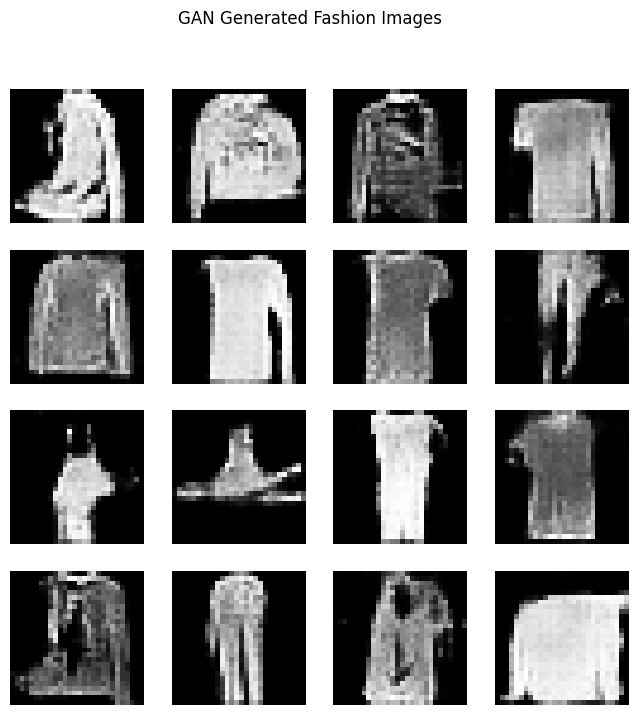

In [ ]:
# Generate Synthetic Images



generator.eval()


with torch.no_grad():

    noise = torch.randn(
        16,
        latent_dim,
        1,
        1,
        device=device
    )

    generated_images = generator(noise)



plt.figure(figsize=(8,8))


for i in range(16):

    plt.subplot(4,4,i+1)

    image = generated_images[i].cpu().squeeze()

    # Convert [-1,1] to [0,1]

    image = (image + 1) / 2


    plt.imshow(
        image,
        cmap="gray"
    )

    plt.axis("off")


plt.suptitle(
    "GAN Generated Fashion Images"
)

plt.show()

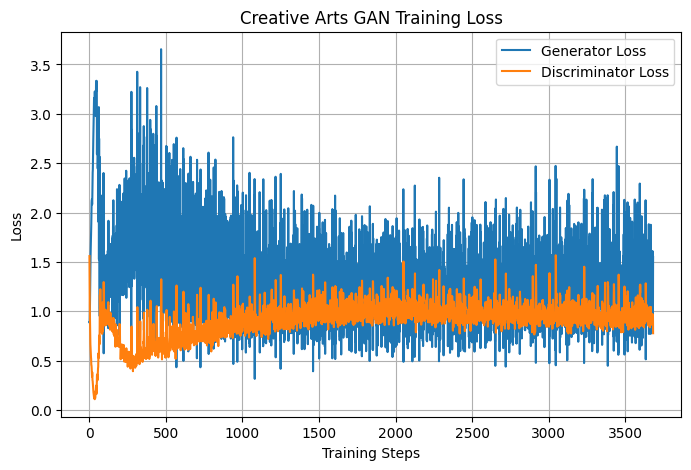

In [ ]:
# GAN Loss Curves



plt.figure(figsize=(8,5))


plt.plot(
    generator_losses,
    label="Generator Loss"
)


plt.plot(
    discriminator_losses,
    label="Discriminator Loss"
)


plt.xlabel(
    "Training Steps"
)

plt.ylabel(
    "Loss"
)


plt.title(
    "Creative Arts GAN Training Loss"
)


plt.legend()

plt.grid(True)


plt.savefig(
    "creative_gan_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

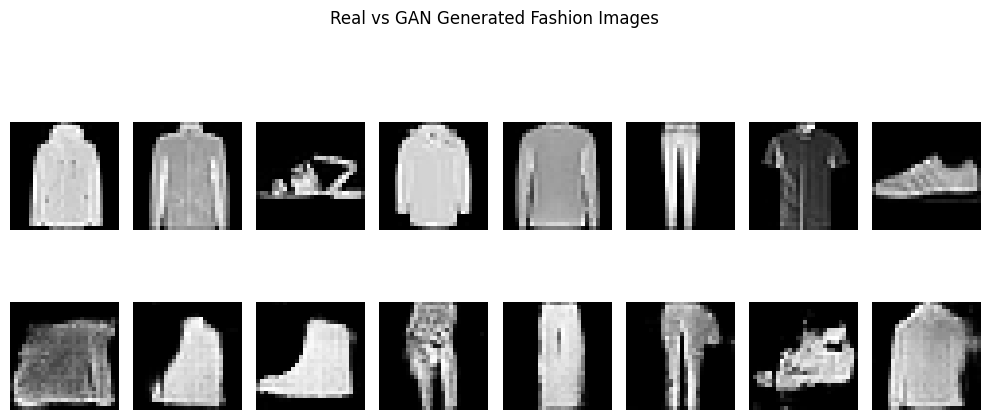

In [ ]:
# Real vs Generated Image Comparison


generator.eval()


with torch.no_grad():

    # Get real images

    real_images, _ = next(iter(train_loader))

    real_images = real_images[:8].to(device)


    # Generate fake images

    noise = torch.randn(
        8,
        latent_dim,
        1,
        1,
        device=device
    )


    fake_images = generator(noise)



plt.figure(figsize=(10,5))


for i in range(8):

    # Real images

    plt.subplot(2,8,i+1)

    real_img = real_images[i].cpu().squeeze()

    real_img = (real_img + 1) / 2


    plt.imshow(
        real_img,
        cmap="gray"
    )

    plt.axis("off")

    if i == 0:
        plt.ylabel("Real")



    # Generated images

    plt.subplot(2,8,i+9)

    fake_img = fake_images[i].cpu().squeeze()

    fake_img = (fake_img + 1) / 2


    plt.imshow(
        fake_img,
        cmap="gray"
    )

    plt.axis("off")

    if i == 0:
        plt.ylabel("GAN")



plt.suptitle(
    "Real vs GAN Generated Fashion Images"
)


plt.tight_layout()


plt.savefig(
    "real_vs_generated_fashion_gan.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
#  Quantitative Comparison


from sklearn.metrics import mean_squared_error


# Generate more images

generator.eval()


with torch.no_grad():

    noise = torch.randn(
        100,
        latent_dim,
        1,
        1,
        device=device
    )


    generated_images = generator(noise)



# Get real images

real_images, _ = next(iter(train_loader))


real_images = real_images[:100].to(device)



# Flatten images

real_flat = real_images.cpu().numpy().reshape(
    100,
    -1
)


fake_flat = generated_images.cpu().numpy().reshape(
    100,
    -1
)



# Calculate MSE

mse_score = mean_squared_error(
    real_flat,
    fake_flat
)


print(
    "Mean Squared Error between real and generated images:",
    mse_score
)

Mean Squared Error between real and generated images: 0.6841986775398254


# Part 2.3:
# Creative AI - QuickDraw "birthday cake" Subset.

In [ ]:

# Download QuickDraw Birthday Cake Dataset


import requests
import numpy as np
import gzip
import os


url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/birthday%20cake.npy"


filename = "birthday_cake.npy"


if not os.path.exists(filename):

    response = requests.get(url)

    open(filename, "wb").write(response.content)


print("Dataset downloaded successfully")

Dataset downloaded successfully


In [ ]:
#  Load Dataset


import numpy as np
import matplotlib.pyplot as plt


# Load QuickDraw data

images = np.load(
    "birthday_cake.npy"
)


print("Dataset shape:")
print(images.shape)


print("\nSingle image shape:")
print(images[0].shape)

Dataset shape:
(144982, 784)

Single image shape:
(784,)


In [ ]:
# Reshape QuickDraw Images



images = images.reshape(
    -1,
    28,
    28
)


print(images.shape)

(144982, 28, 28)


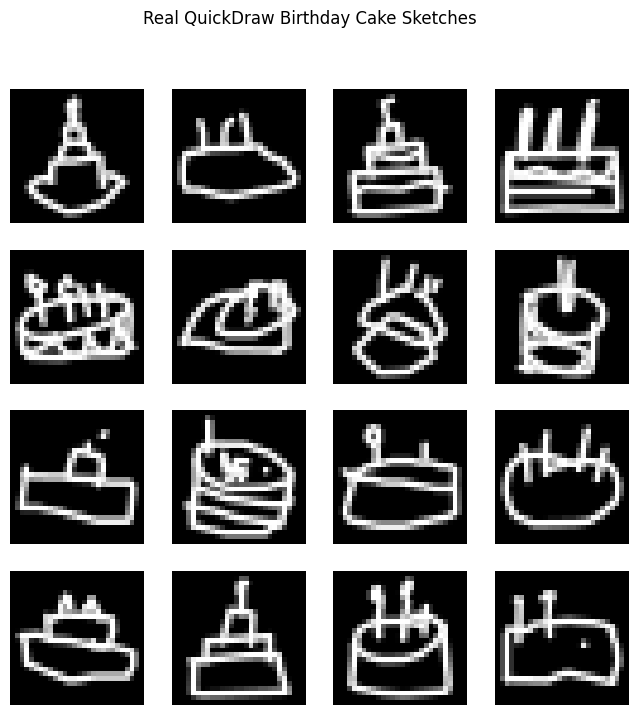

In [ ]:
# Visualise Real Birthday Cake Sketches
#  Display Real Samples



plt.figure(figsize=(8,8))


for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        images[i],
        cmap="gray"
    )

    plt.axis("off")


plt.suptitle(
    "Real QuickDraw Birthday Cake Sketches"
)


plt.show()

In [ ]:
# Preprocess QuickDraw Images + Create DataLoader

import torch
from torch.utils.data import TensorDataset, DataLoader


# Convert to float

images = images.astype("float32")


# Normalize pixels:
# Original range: 0-255
# New range: -1 to 1

images = (images / 127.5) - 1



# Add channel dimension

images = np.expand_dims(
    images,
    axis=1
)


print("Final image shape:")
print(images.shape)



# Convert to PyTorch tensor

images_tensor = torch.tensor(
    images
)



# Create dataset

dataset = TensorDataset(
    images_tensor
)



# DataLoader

batch_size = 128


train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)


print("Number of training images:", len(dataset))

Final image shape:
(144982, 1, 28, 28)
Number of training images: 144982


In [ ]:
# Build DCGAN Generator and Discriminator for QuickDraw sketches
# DCGAN Architecture


import torch.nn as nn


latent_dim = 100


# ==========================
# Generator
# ==========================

class Generator(nn.Module):

    def __init__(self):

        super().__init__()


        self.model = nn.Sequential(

            # 100 x 1 x 1 -> 128 x 7 x 7

            nn.ConvTranspose2d(
                latent_dim,
                128,
                kernel_size=7,
                stride=1,
                padding=0
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(True),


            # 128 x 7 x 7 -> 64 x 14 x 14

            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(True),


            # 64 x 14 x 14 -> 1 x 28 x 28

            nn.ConvTranspose2d(
                64,
                1,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.Tanh()
        )


    def forward(self,x):

        return self.model(x)



# ==========================
# Discriminator
# ==========================

class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()


        self.model = nn.Sequential(

            # 1 x 28 x 28 -> 64 x 14 x 14

            nn.Conv2d(
                1,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            # 64 x 14 x 14 -> 128 x 7 x 7

            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            nn.Flatten(),


            nn.Linear(
                128*7*7,
                1
            ),

            nn.Sigmoid()
        )


    def forward(self,x):

        return self.model(x)



# Create models

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


generator = Generator().to(device)

discriminator = Discriminator().to(device)



print(device)

print(generator)

print(discriminator)

cpu
Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Tanh()
  )
)
Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Linear(in_features=6272, out_fea

In [ ]:
# Create Smaller Training Dataset (CPU)
#  Reduce Dataset for CPU Training



from torch.utils.data import Subset


# Use 20000 images for faster training

subset_size = 20000


small_dataset = Subset(
    dataset,
    range(subset_size)
)


train_loader = DataLoader(
    small_dataset,
    batch_size=128,
    shuffle=True
)


print(
    "Training samples:",
    len(small_dataset)
)

Training samples: 20000


In [ ]:
# Loss and Optimizers



import torch.optim as optim


loss_function = nn.BCELoss()


learning_rate = 0.0002


optimizer_generator = optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(0.5,0.999)
)


optimizer_discriminator = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5,0.999)
)


generator_losses = []
discriminator_losses = []


print("Optimizers created successfully")

Optimizers created successfully


In [ ]:
# QuickDraw Birthday Cake DCGAN Training Loop
num_epochs = 20


for epoch in range(num_epochs):

    for real_images, in train_loader:


        real_images = real_images.to(device)

        batch_size = real_images.size(0)


        # Labels

        real_labels = torch.ones(
            batch_size,
            1,
            device=device
        )

        fake_labels = torch.zeros(
            batch_size,
            1,
            device=device
        )


        # ==========================
        # Train Discriminator
        # ==========================

        discriminator.zero_grad()


        real_output = discriminator(
            real_images
        )


        real_loss = loss_function(
            real_output,
            real_labels
        )


        # Generate fake images

        noise = torch.randn(
            batch_size,
            latent_dim,
            1,
            1,
            device=device
        )


        fake_images = generator(
            noise
        )


        fake_output = discriminator(
            fake_images.detach()
        )


        fake_loss = loss_function(
            fake_output,
            fake_labels
        )


        discriminator_loss = (
            real_loss + fake_loss
        )


        discriminator_loss.backward()

        optimizer_discriminator.step()



        # ==========================
        # Train Generator
        # ==========================


        generator.zero_grad()


        fake_output = discriminator(
            fake_images
        )


        generator_loss = loss_function(
            fake_output,
            real_labels
        )


        generator_loss.backward()

        optimizer_generator.step()



        # Store losses

        generator_losses.append(
            generator_loss.item()
        )

        discriminator_losses.append(
            discriminator_loss.item()
        )



    print(
        f"Epoch {epoch} | "
        f"D Loss: {discriminator_loss.item():.4f} | "
        f"G Loss: {generator_loss.item():.4f}"
    )

Epoch 0 | D Loss: 0.5578 | G Loss: 1.5657
Epoch 1 | D Loss: 0.3215 | G Loss: 1.7222
Epoch 2 | D Loss: 0.1851 | G Loss: 2.7709
Epoch 3 | D Loss: 0.1593 | G Loss: 3.0606
Epoch 4 | D Loss: 0.2652 | G Loss: 4.8994
Epoch 5 | D Loss: 0.1530 | G Loss: 3.6996
Epoch 6 | D Loss: 0.0952 | G Loss: 3.7548
Epoch 7 | D Loss: 0.1267 | G Loss: 3.1939
Epoch 8 | D Loss: 0.1037 | G Loss: 3.7667
Epoch 9 | D Loss: 1.1352 | G Loss: 3.3854
Epoch 10 | D Loss: 0.0834 | G Loss: 3.9326
Epoch 11 | D Loss: 0.2343 | G Loss: 1.9126
Epoch 12 | D Loss: 0.1748 | G Loss: 4.7597
Epoch 13 | D Loss: 0.1821 | G Loss: 4.0650
Epoch 14 | D Loss: 0.3748 | G Loss: 2.5432
Epoch 15 | D Loss: 0.1465 | G Loss: 3.6241
Epoch 16 | D Loss: 0.1074 | G Loss: 3.3905
Epoch 17 | D Loss: 0.0575 | G Loss: 4.0345
Epoch 18 | D Loss: 0.1155 | G Loss: 2.8801
Epoch 19 | D Loss: 0.0756 | G Loss: 3.7765


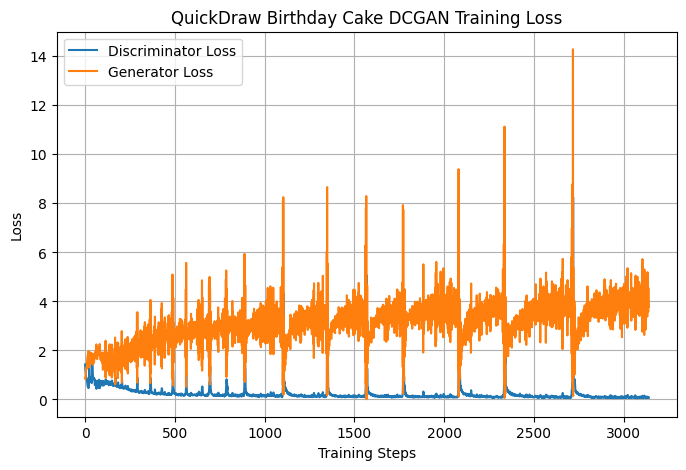

In [ ]:
# GAN Training Loss Curves


import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))


plt.plot(
    discriminator_losses,
    label="Discriminator Loss"
)


plt.plot(
    generator_losses,
    label="Generator Loss"
)


plt.xlabel(
    "Training Steps"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "QuickDraw Birthday Cake DCGAN Training Loss"
)


plt.legend()


plt.grid(True)


plt.savefig(
    "quickdraw_gan_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

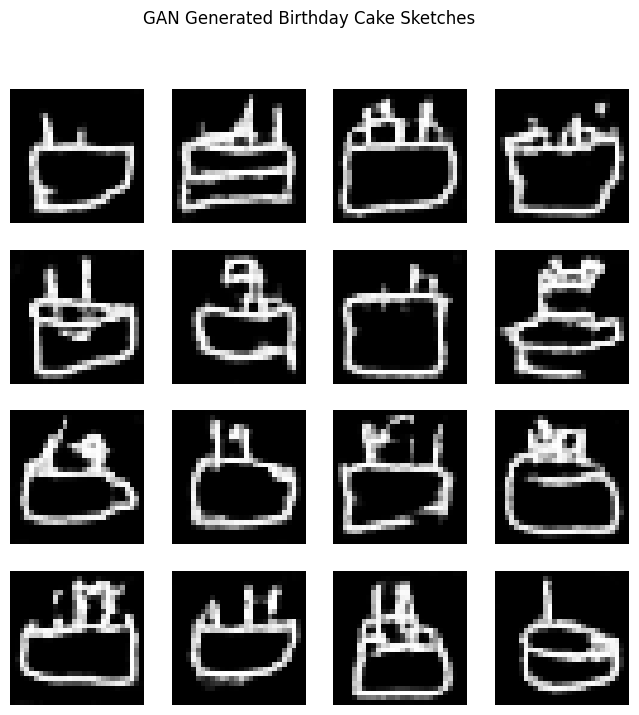

In [ ]:
#  Generate Synthetic Birthday Cakes



generator.eval()


with torch.no_grad():

    noise = torch.randn(
        16,
        latent_dim,
        1,
        1,
        device=device
    )


    generated_images = generator(
        noise
    )



plt.figure(figsize=(8,8))


for i in range(16):

    plt.subplot(
        4,
        4,
        i+1
    )


    image = generated_images[i].cpu().squeeze()


    # Convert back from [-1,1] to [0,1]

    image = (image + 1) / 2


    plt.imshow(
        image,
        cmap="gray"
    )


    plt.axis("off")



plt.suptitle(
    "GAN Generated Birthday Cake Sketches"
)


plt.savefig(
    "generated_quickdraw_birthday_cakes.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

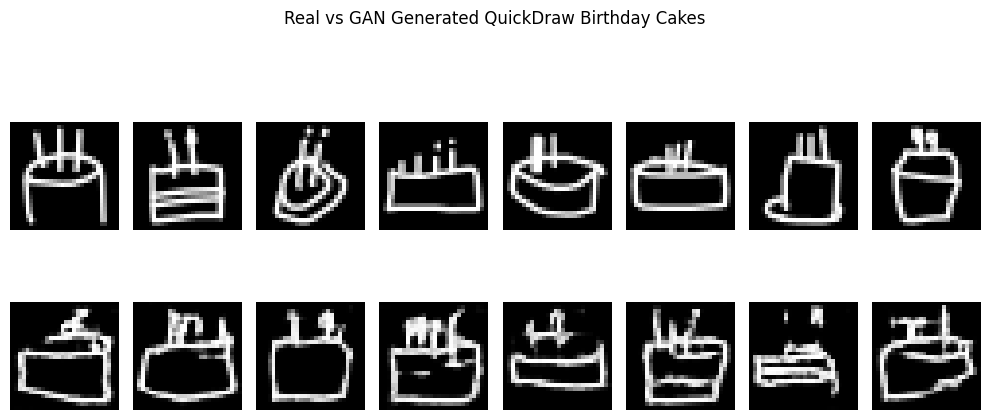

In [ ]:
#  Real vs Generated Comparison



generator.eval()


with torch.no_grad():

    # Get real samples

    real_images, = next(iter(train_loader))

    real_images = real_images[:8].to(device)


    # Generate fake samples

    noise = torch.randn(
        8,
        latent_dim,
        1,
        1,
        device=device
    )


    fake_images = generator(
        noise
    )



plt.figure(figsize=(10,5))


for i in range(8):


    # Real images

    plt.subplot(
        2,
        8,
        i+1
    )


    real_img = real_images[i].cpu().squeeze()


    real_img = (real_img + 1) / 2


    plt.imshow(
        real_img,
        cmap="gray"
    )


    plt.axis("off")


    if i == 0:
        plt.ylabel("Real")



    # Generated images

    plt.subplot(
        2,
        8,
        i+9
    )


    fake_img = fake_images[i].cpu().squeeze()


    fake_img = (fake_img + 1) / 2


    plt.imshow(
        fake_img,
        cmap="gray"
    )


    plt.axis("off")


    if i == 0:
        plt.ylabel("GAN")



plt.suptitle(
    "Real vs GAN Generated QuickDraw Birthday Cakes"
)


plt.tight_layout()


plt.savefig(
    "real_vs_generated_quickdraw_cakes.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
#  Prepare FID Data

# Ensure torchmetrics and its image dependencies are installed
!pip install -U torchmetrics[image]

import sys
# Clear torchmetrics and its submodules from sys.modules to force a fresh import
# This ensures the internal _TORCH_FIDELITY_AVAILABLE flag is re-evaluated.
for module_name in list(sys.modules.keys()):
    if module_name.startswith('torchmetrics') or module_name.startswith('torch_fidelity'):
        del sys.modules[module_name]

from torchmetrics.image.fid import FrechetInceptionDistance
import torchvision.transforms as transforms


fid = FrechetInceptionDistance(
    feature=2048
)


resize = transforms.Compose([
    transforms.Resize(
        (299,299)
    )
])


print("FID metric created")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 30.2 MB/s eta 0:00:00


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 121MB/s]


FID metric created


In [ ]:
# Cell 13: QuickDraw Birthday Cake FID Score
# ============================================================


generator.eval()


real_images_list = []
fake_images_list = []


with torch.no_grad():

    for real_images, in train_loader:


        real_images = real_images.to(device)


        batch_size = real_images.size(0)


        noise = torch.randn(
            batch_size,
            latent_dim,
            1,
            1,
            device=device
        )


        fake_images = generator(
            noise
        )


        real_images_list.append(
            real_images.cpu()
        )


        fake_images_list.append(
            fake_images.cpu()
        )


        # use first 10 batches only

        if len(real_images_list) == 10:
            break



real_images = torch.cat(
    real_images_list
)


fake_images = torch.cat(
    fake_images_list
)



print(
    "Real images:",
    real_images.shape
)


print(
    "Fake images:",
    fake_images.shape
)

Real images: torch.Size([1280, 1, 28, 28])
Fake images: torch.Size([1280, 1, 28, 28])


In [ ]:
#  Compute FID



for real, fake in zip(
    real_images[:5],
    fake_images[:5]
):


    # Add batch dimension

    real = real.unsqueeze(0)
    fake = fake.unsqueeze(0)



    # Resize

    real = resize(real)
    fake = resize(fake)



    # Convert grayscale to RGB

    real = real.repeat(
        1,3,1,1
    )

    fake = fake.repeat(
        1,3,1,1
    )



    # Convert [-1,1] to uint8

    real = (
        ((real + 1) / 2) * 255
    ).clamp(0,255).to(torch.uint8)


    fake = (
        ((fake + 1) / 2) * 255
    ).clamp(0,255).to(torch.uint8)



    fid.update(
        real,
        real=True
    )


    fid.update(
        fake,
        real=False
    )



score = fid.compute()


print(
    "QuickDraw Birthday Cake FID Score:",
    score.item()
)

QuickDraw Birthday Cake FID Score: 184.60711669921875


In [ ]:
# Save QuickDraw GAN Models


torch.save(
    generator.state_dict(),
    "quickdraw_birthday_cake_generator.pth"
)


torch.save(
    discriminator.state_dict(),
    "quickdraw_birthday_cake_discriminator.pth"
)


print("QuickDraw GAN models saved successfully")

QuickDraw GAN models saved successfully


# Extra Credit — QuickDraw Cats GAN

In [ ]:
# Extra Credit: QuickDraw Cats Dataset

import requests
import os


url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/cat.npy"


filename = "cat.npy"


if not os.path.exists(filename):

    response = requests.get(url)

    open(filename, "wb").write(response.content)


print("Cat dataset downloaded successfully")

Cat dataset downloaded successfully


In [ ]:
# Load Cat Dataset

import numpy as np


cat_images = np.load(
    "cat.npy"
)


print(
    "Dataset shape:",
    cat_images.shape
)

Dataset shape: (123202, 784)


In [ ]:
# Reshape to 28x28

cat_images = cat_images.reshape(
    -1,
    28,
    28
)


print(cat_images.shape)

(123202, 28, 28)


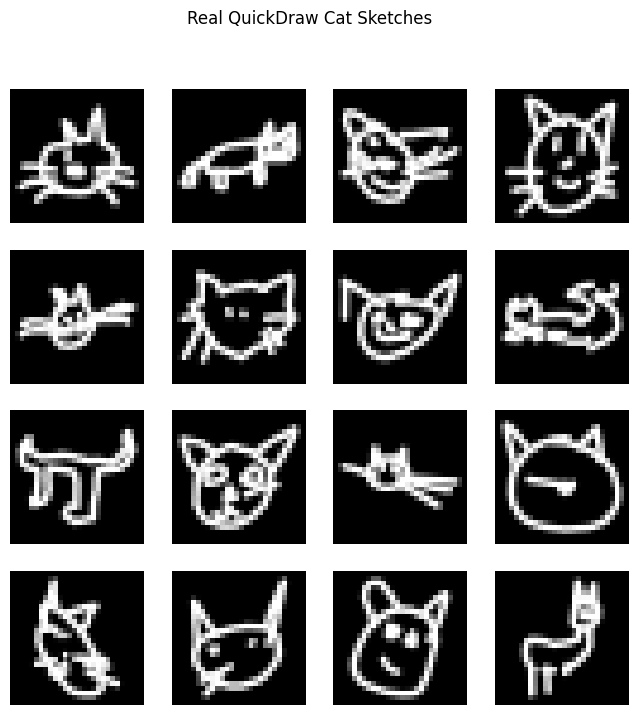

In [ ]:
# Visualise Real Cat Sketches
import matplotlib.pyplot as plt


plt.figure(figsize=(8,8))


for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        cat_images[i],
        cmap="gray"
    )

    plt.axis("off")


plt.suptitle(
    "Real QuickDraw Cat Sketches"
)


plt.savefig(
    "real_quickdraw_cats.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# Prepare Dataset


# Normalize

cat_images = cat_images.astype(
    "float32"
)


cat_images = (
    cat_images / 127.5
) - 1



# Add channel dimension

cat_images = np.expand_dims(
    cat_images,
    axis=1
)



print(cat_images.shape)

(123202, 1, 28, 28)


In [ ]:
# Create DataLoader


import torch
from torch.utils.data import TensorDataset, DataLoader, Subset


cat_tensor = torch.tensor(
    cat_images
)


cat_dataset = TensorDataset(
    cat_tensor
)


cat_dataset = Subset(
    cat_dataset,
    range(20000)
)


cat_loader = DataLoader(
    cat_dataset,
    batch_size=128,
    shuffle=True
)


print(
    "Training samples:",
    len(cat_dataset)
)

Training samples: 20000


In [ ]:
# Reset Generator and Discriminator for Cats


# Create New DCGAN Models for Cats



generator_cat = Generator().to(device)

discriminator_cat = Discriminator().to(device)


print(generator_cat)

print(discriminator_cat)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Tanh()
  )
)
Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Linear(in_features=6272, out_feature

In [ ]:
# Loss and Optimizers for Cats


# Optimizers for Cat GAN


loss_function = nn.BCELoss()


optimizer_generator_cat = torch.optim.Adam(
    generator_cat.parameters(),
    lr=0.0002,
    betas=(0.5,0.999)
)


optimizer_discriminator_cat = torch.optim.Adam(
    discriminator_cat.parameters(),
    lr=0.0002,
    betas=(0.5,0.999)
)


generator_losses_cat = []

discriminator_losses_cat = []


print("Cat GAN optimizers ready")

Cat GAN optimizers ready


In [ ]:
# Train Cat DCGAN

num_epochs = 20


for epoch in range(num_epochs):

    for real_images, in cat_loader:


        real_images = real_images.to(device)

        batch_size = real_images.size(0)


        real_labels = torch.ones(
            batch_size,
            1,
            device=device
        )


        fake_labels = torch.zeros(
            batch_size,
            1,
            device=device
        )


        # Train discriminator

        discriminator_cat.zero_grad()


        real_output = discriminator_cat(
            real_images
        )


        real_loss = loss_function(
            real_output,
            real_labels
        )


        noise = torch.randn(
            batch_size,
            latent_dim,
            1,
            1,
            device=device
        )


        fake_images = generator_cat(
            noise
        )


        fake_output = discriminator_cat(
            fake_images.detach()
        )


        fake_loss = loss_function(
            fake_output,
            fake_labels
        )


        d_loss = real_loss + fake_loss


        d_loss.backward()

        optimizer_discriminator_cat.step()



        # Train generator

        generator_cat.zero_grad()


        fake_output = discriminator_cat(
            fake_images
        )


        g_loss = loss_function(
            fake_output,
            real_labels
        )


        g_loss.backward()

        optimizer_generator_cat.step()



        generator_losses_cat.append(
            g_loss.item()
        )


        discriminator_losses_cat.append(
            d_loss.item()
        )


    print(
        f"Epoch {epoch} | "
        f"D Loss: {d_loss.item():.4f} | "
        f"G Loss: {g_loss.item():.4f}"
    )


Epoch 0 | D Loss: 0.8100 | G Loss: 1.9003
Epoch 1 | D Loss: 0.4288 | G Loss: 1.8220
Epoch 2 | D Loss: 0.2827 | G Loss: 2.0846
Epoch 3 | D Loss: 0.1870 | G Loss: 2.9047
Epoch 4 | D Loss: 0.2697 | G Loss: 2.4387
Epoch 5 | D Loss: 0.7356 | G Loss: 4.0831
Epoch 6 | D Loss: 0.1487 | G Loss: 3.0736
Epoch 7 | D Loss: 0.2006 | G Loss: 2.0248
Epoch 8 | D Loss: 0.1301 | G Loss: 3.1092
Epoch 9 | D Loss: 0.1555 | G Loss: 3.3492
Epoch 10 | D Loss: 0.1511 | G Loss: 2.6674
Epoch 11 | D Loss: 0.2743 | G Loss: 1.7915
Epoch 12 | D Loss: 0.1301 | G Loss: 4.3764
Epoch 13 | D Loss: 0.1953 | G Loss: 2.7902
Epoch 14 | D Loss: 0.0789 | G Loss: 3.9731
Epoch 15 | D Loss: 0.0888 | G Loss: 3.2783
Epoch 16 | D Loss: 0.1157 | G Loss: 3.5566
Epoch 17 | D Loss: 0.0612 | G Loss: 4.5854
Epoch 18 | D Loss: 0.6664 | G Loss: 6.7895
Epoch 19 | D Loss: 0.1492 | G Loss: 4.4735


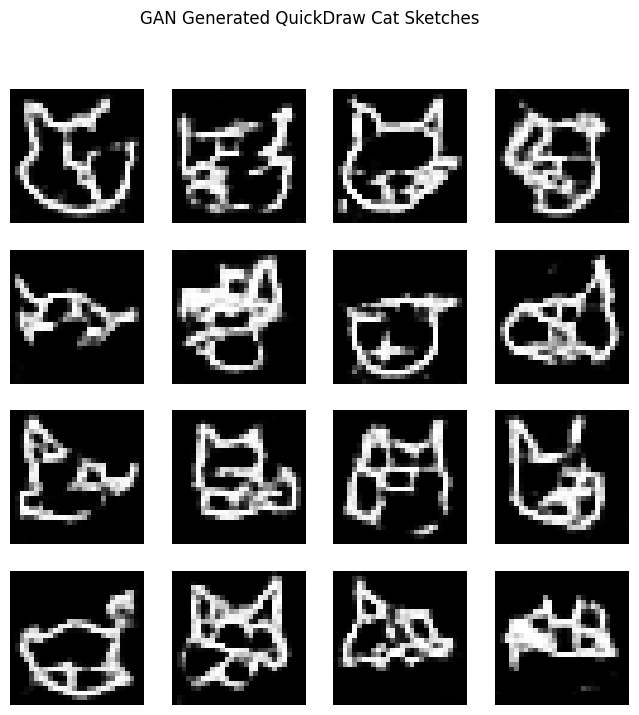

In [ ]:
# Generate QuickDraw Cat Sketches
# ============================================================


generator_cat.eval()


with torch.no_grad():

    noise = torch.randn(
        16,
        latent_dim,
        1,
        1,
        device=device
    )


    generated_cats = generator_cat(
        noise
    )



plt.figure(figsize=(8,8))


for i in range(16):

    plt.subplot(
        4,
        4,
        i+1
    )


    img = generated_cats[i].cpu().squeeze()


    img = (img + 1) / 2


    plt.imshow(
        img,
        cmap="gray"
    )


    plt.axis("off")



plt.suptitle(
    "GAN Generated QuickDraw Cat Sketches"
)


plt.savefig(
    "generated_quickdraw_cats.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# QuickDraw Cats FID Calculation



from torchmetrics.image.fid import FrechetInceptionDistance


fid_cat = FrechetInceptionDistance(
    feature=2048
)


generator_cat.eval()


real_cat_list = []
fake_cat_list = []


with torch.no_grad():

    for real_images, in cat_loader:


        real_images = real_images.to(device)


        batch_size = real_images.size(0)


        noise = torch.randn(
            batch_size,
            latent_dim,
            1,
            1,
            device=device
        )


        fake_images = generator_cat(
            noise
        )


        real_cat_list.append(
            real_images.cpu()
        )


        fake_cat_list.append(
            fake_images.cpu()
        )


        # first 5 batches only (CPU)

        if len(real_cat_list) == 5:
            break



real_cat_images = torch.cat(
    real_cat_list
)


fake_cat_images = torch.cat(
    fake_cat_list
)


print(
    "Real cats:",
    real_cat_images.shape
)


print(
    "Fake cats:",
    fake_cat_images.shape
)

Real cats: torch.Size([640, 1, 28, 28])
Fake cats: torch.Size([640, 1, 28, 28])


In [ ]:
# Compute Cat FID
# ============================================================


for real, fake in zip(
    real_cat_images[:5],
    fake_cat_images[:5]
):


    real = real.unsqueeze(0)
    fake = fake.unsqueeze(0)


    # Resize to Inception input

    real = resize(real)
    fake = resize(fake)


    # grayscale -> RGB

    real = real.repeat(
        1,3,1,1
    )


    fake = fake.repeat(
        1,3,1,1
    )


    # Convert to uint8

    real = (
        ((real + 1) / 2) * 255
    ).clamp(0,255).to(torch.uint8)


    fake = (
        ((fake + 1) / 2) * 255
    ).clamp(0,255).to(torch.uint8)



    fid_cat.update(
        real,
        real=True
    )


    fid_cat.update(
        fake,
        real=False
    )



cat_fid_score = fid_cat.compute()


print(
    "QuickDraw Cats FID Score:",
    cat_fid_score.item()
)

QuickDraw Cats FID Score: 153.69320678710938
